# GFlowNet for Sequence Generation

This notebook demonstrates training a GFlowNet (Generative Flow Network) to generate sequences.

**GFlowNet learns to sample sequences with probability proportional to their reward:**
$$P(x) \propto R(x)$$

## Modules
- `gfn.env` - Environment (states, actions, transitions)
- `gfn.model` - Trajectory Balance model
- `gfn.reward` - Reward functions
- `gfn.training` - Training loop
- `gfn.visualization` - Plotting utilities

In [1]:
# Imports
import matplotlib.pyplot as plt

from gfn import (
    train,
    TrainingConfig,
    generate_greedy_trajectory,
    ACTIONS_LIST,
    DEFAULT_TARGETS,
)
from gfn.reward import TargetMatchReward
from gfn.visualization import (
    plot_training_curves,
    plot_reward_distribution,
    plot_state_space,
    plot_flow_network,
    print_policy,
)

%matplotlib inline

## 1. Configuration

In [2]:
# Training configuration
config = TrainingConfig(
    seed=43,
    n_hid_units=32,
    n_episodes=20_000,
    learning_rate=3e-3,
    update_freq=4,
    uniform_backward=True,
)

print("Training Configuration:")
print(f"  Seed: {config.seed}")
print(f"  Hidden units: {config.n_hid_units}")
print(f"  Episodes: {config.n_episodes}")
print(f"  Learning rate: {config.learning_rate}")
print(f"  Update frequency: {config.update_freq}")
print(f"  Action steps per episode: {config.n_action_steps}")

Training Configuration:
  Seed: 43
  Hidden units: 32
  Episodes: 20000
  Learning rate: 0.003
  Update frequency: 4
  Action steps per episode: 4


In [3]:
# Define target sequences (reward = 1.0 for these, 0.1 otherwise)
target_sequences = [
    ['A', 'B', 'B', 'C'], 
    ['A', 'B', 'C', 'ε'], 
    ['C', 'A', 'C', 'C'], 
    ['C', 'B', 'A', 'ε'], 
    ['C', 'C', 'B', 'A'], 
    ['C', 'C', 'C', 'A'],
]

# Or use the default targets
# target_sequences = DEFAULT_TARGETS

# Create reward function
reward_fn = TargetMatchReward(target_sequences, r_min=0.1)

print("Target sequences:")
for seq in target_sequences:
    unpadded = ''.join(s for s in seq if s != 'ε')
    print(f"  {unpadded}")

Target sequences:
  ABBC
  ABC
  CACC
  CBA
  CCBA
  CCCA


## 2. Training

In [4]:
# Train the GFlowNet model
result = train(reward_fn, config, verbose=True)

Training: 100%|██████| 20000/20000 [00:25<00:00, 788.48it/s]


## 3. Training Results

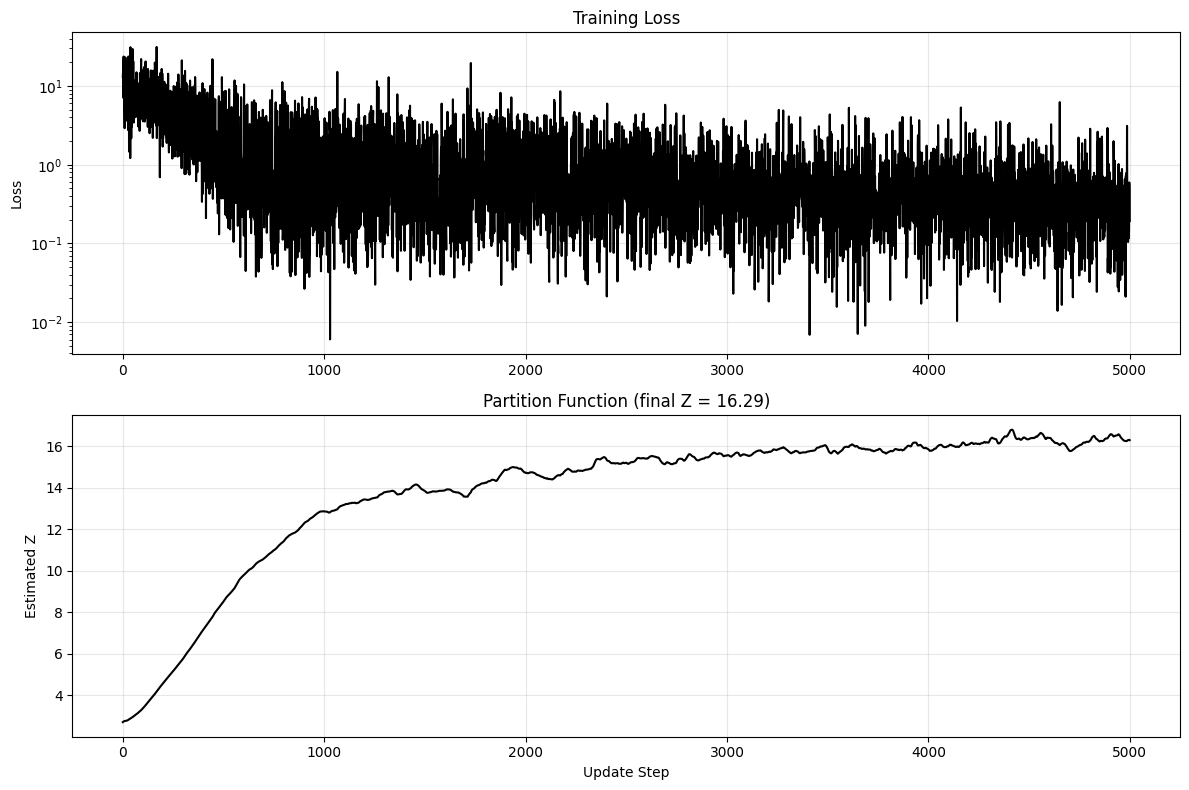


Final partition function estimate Z = 16.29


In [5]:
# Plot training curves
fig = plot_training_curves(result)
plt.show()

print(f"\nFinal partition function estimate Z = {result.final_Z:.2f}")

In [6]:
# Show reward distribution of sampled states
plot_reward_distribution(result, reward_fn)


Reward Distribution (20000 samples):
----------------------------------------
  Reward 0.10: 81.0%
  Reward 1.00: 19.0%


## 4. Analysis

In [7]:
# Generate the most likely (greedy) trajectory
trajectory = generate_greedy_trajectory(result.model)

print("Most likely trajectory (greedy):")
for t, state in enumerate(trajectory):
    seq = ''.join(s for s in state[1] if s != 'ε') or 'ε'
    print(f"  t={t}: {seq}")

Most likely trajectory (greedy):
  t=0: ε
  t=1: C
  t=2: CC
  t=3: CCA
  t=4: CCBA


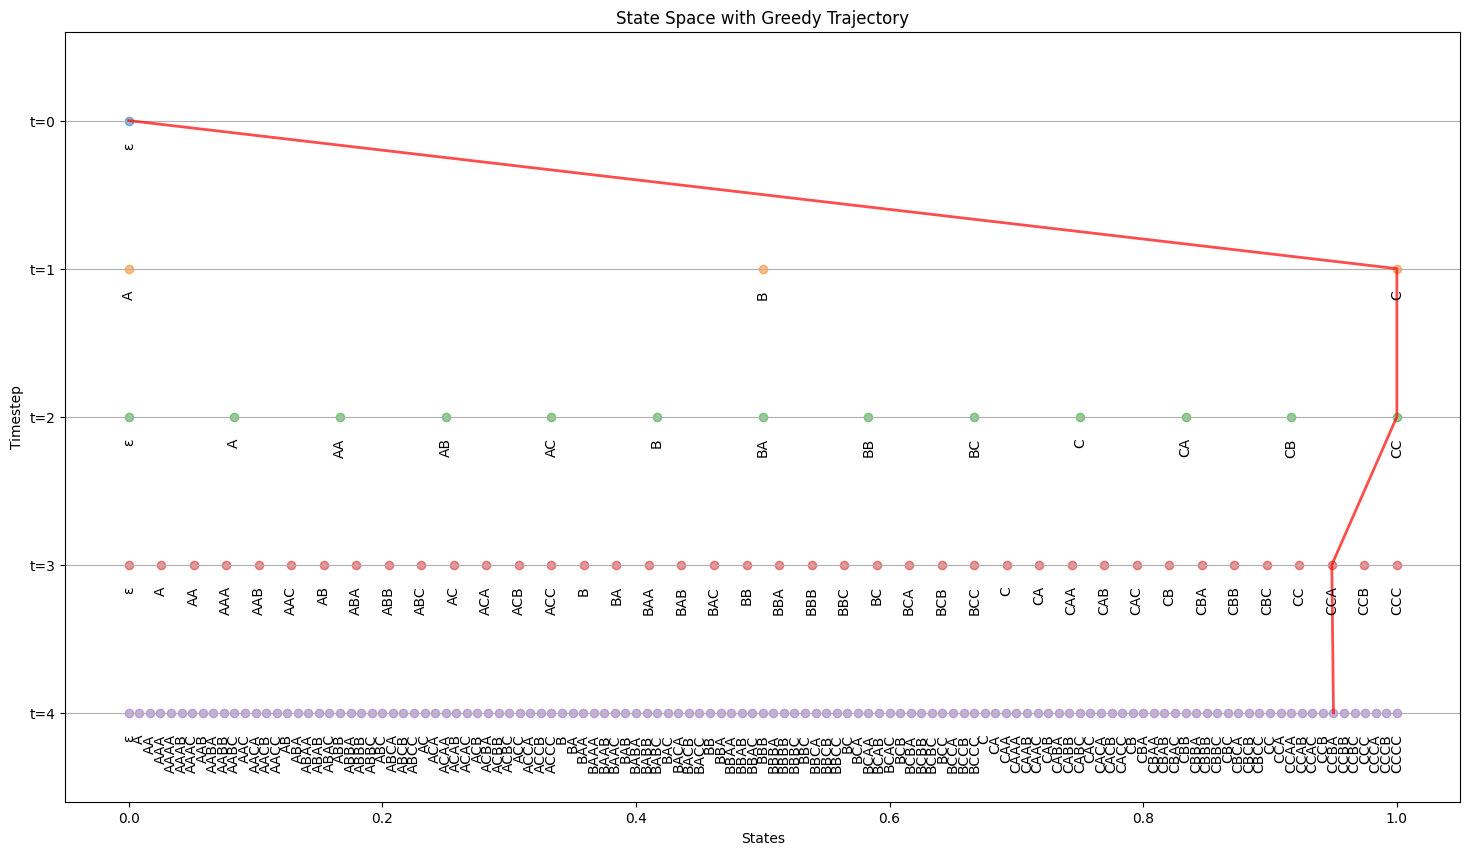

In [8]:
# Visualize state space with the greedy trajectory
fig = plot_state_space(trajectory=trajectory)
plt.title("State Space with Greedy Trajectory")
plt.show()


Max flow trajectories (greedy traceback):

Trajectory for target 'ABBC':
  t=0: ε
  t=1: A
  t=2: AB
  t=3: ABC
  t=4: ABBC

Trajectory for target 'ABC':
  t=0: ε
  t=1: A
  t=2: AB
  t=3: ABC
  t=4: ABC

Trajectory for target 'CACC':
  t=0: ε
  t=1: A
  t=2: CA
  t=3: CAC
  t=4: CACC

Trajectory for target 'CBA':
  t=0: ε
  t=1: C
  t=2: CB
  t=3: CBA
  t=4: CBA

Trajectory for target 'CCBA':
  t=0: ε
  t=1: C
  t=2: CB
  t=3: CBA
  t=4: CCBA

Trajectory for target 'CCCA':
  t=0: ε
  t=1: A
  t=2: CA
  t=3: CCA
  t=4: CCCA


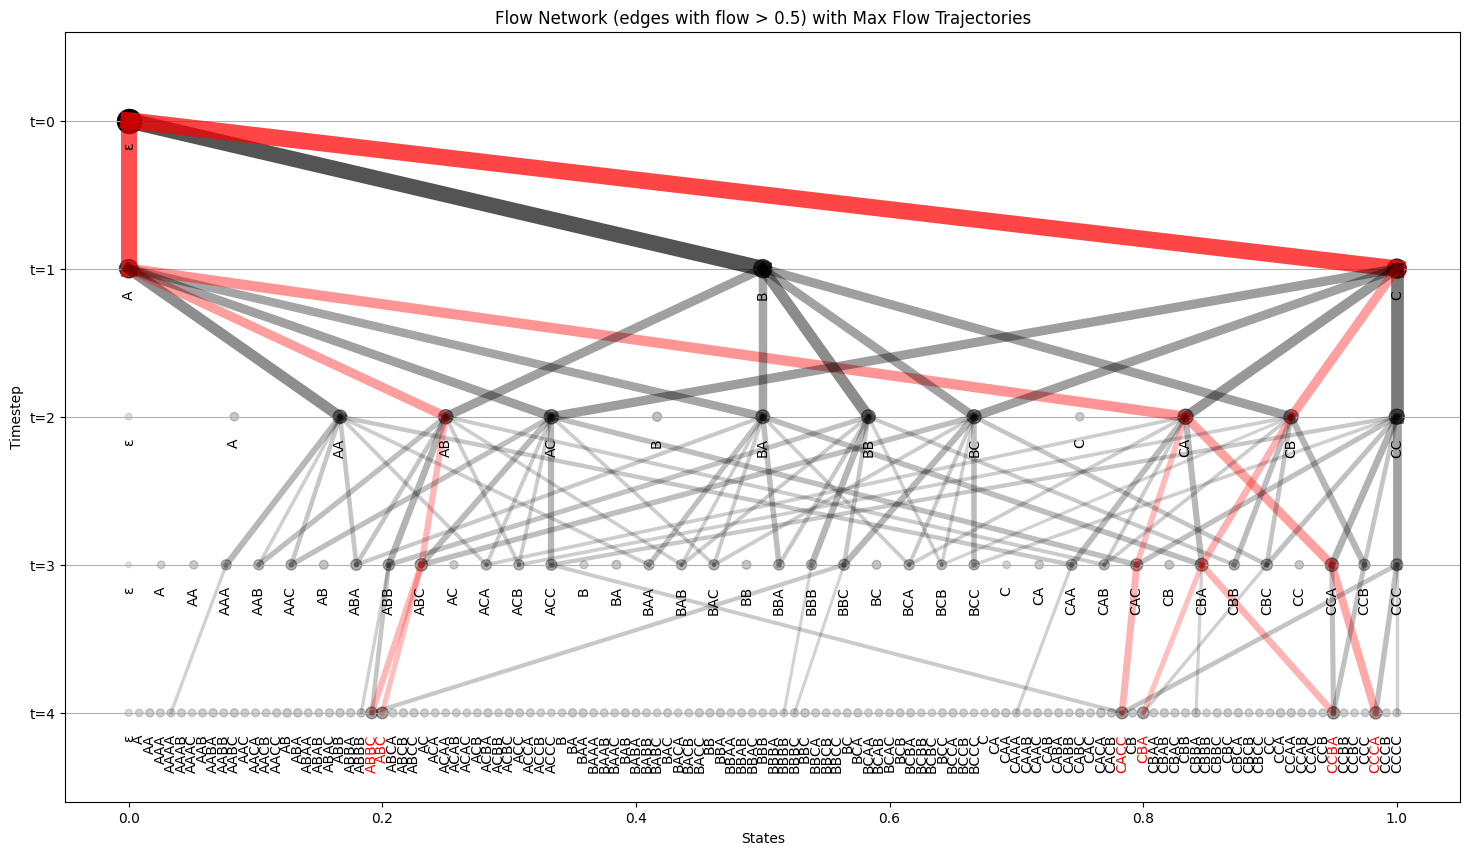

In [11]:
# Visualize flow network with greedy traceback trajectories (red)
# Red lines show the maximum flow path from root to each target
fig = plot_flow_network(
    result.model,
    target_sequences=target_sequences,
    edge_flow_threshold=0.5,
    show_edge_labels=False,
    show_target_trajectory=True,  # 显式设置（默认已开启）
)
plt.show()

## 5. Policy Inspection

In [12]:
# Inspect policy at specific states
test_states = [
    [0, ['ε', 'ε', 'ε', 'ε']],  # Root state
    [2, ['C', 'C', 'ε', 'ε']],   # Intermediate state
    [3, ['C', 'C', 'A', 'ε']],   # Near terminal
]

for state in test_states:
    print_policy(result.model, state)


Policy for state [0, ['ε', 'ε', 'ε', 'ε']]:
--------------------------------------------------
  ('insert', 0, 'A'): 0.320
  ('insert', 0, 'B'): 0.301
  ('insert', 0, 'C'): 0.379

Policy for state [2, ['C', 'C', 'ε', 'ε']]:
--------------------------------------------------
  ('insert', 0, 'A'): 0.070
  ('insert', 0, 'B'): 0.048
  ('insert', 0, 'C'): 0.111
  ('insert', 1, 'A'): 0.105
  ('insert', 1, 'B'): 0.100
  ('insert', 1, 'C'): 0.117
  ('insert', 2, 'A'): 0.194
  ('insert', 2, 'B'): 0.084
  ('insert', 2, 'C'): 0.116
  ('mutate', 0, 'B'): 0.014

Policy for state [3, ['C', 'C', 'A', 'ε']]:
--------------------------------------------------
  ('insert', 0, 'A'): 0.017
  ('insert', 0, 'B'): 0.020
  ('insert', 0, 'C'): 0.165
  ('insert', 1, 'A'): 0.029
  ('insert', 1, 'B'): 0.028
  ('insert', 1, 'C'): 0.161
  ('insert', 2, 'A'): 0.027
  ('insert', 2, 'B'): 0.186
  ('insert', 2, 'C'): 0.168
  ('insert', 3, 'A'): 0.029
  ('insert', 3, 'B'): 0.022
  ('insert', 3, 'C'): 0.021
  ('mutate',

In [13]:
# Show last 20 sampled states
print("Last 20 sampled states:")
for state in result.sampled_states[-20:]:
    seq = ''.join(s for s in state[1] if s != 'ε') or 'ε'
    reward = reward_fn(state[1])
    marker = "✓" if reward > 0.1 else " "
    print(f"  {marker} {seq}")

Last 20 sampled states:
    ABBA
    BAA
  ✓ ABBC
  ✓ CCCA
    BBBC
  ✓ CACC
    ABCC
    BAB
    ABBB
    CACB
    BB
    BCCC
    BBBC
    AC
    ABCB
    CAAB
  ✓ CCBA
    CAAC
    AABA
  ✓ ABC
